In [1]:
from results import compute_figure4, compute_panel_a
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [15]:
baseline_snapshots = pickle.load(open("baseline_snapshots3.b", "rb"))
baseline_batch_snapshots = pickle.load(open("baseline_batch_snapshots3.b", "rb"))
signed_snapshots = pickle.load(open("signed_snapshots3.b", "rb"))
penal_snapshots = pickle.load(open("penal_sweep.b", "rb"))['beta_01']


<Axes: >

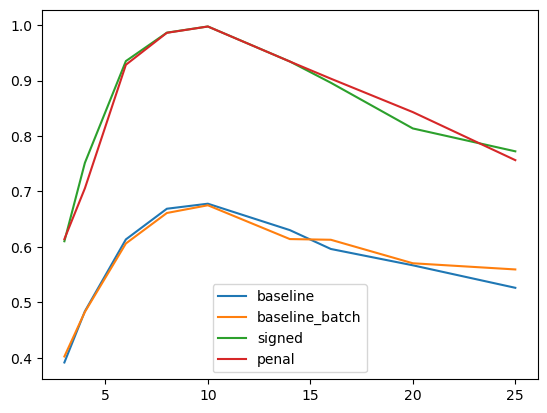

In [16]:
sns.lineplot(data=baseline_snapshots['panel_a']['aggregate_r2'], label="baseline")
sns.lineplot(data=baseline_batch_snapshots['panel_a']['aggregate_r2'], label="baseline_batch")
sns.lineplot(data=signed_snapshots['panel_a']['aggregate_r2'], label="signed")
sns.lineplot(data=penal_snapshots['panel_a']['aggregate_r2'], label="penal")


In [5]:
baseline_snapshots['panel_c'].keys()

dict_keys(['k_values', 'phi_matrices', 'atom_order', 'atom_dominant_manifold', 'atom_manifold_scores', 'cond_rho_G', 'instance_names', 'instance_ki'])

## Figure 4D — Interactive 3D manifold reconstruction

For each manifold instance, greedy OMP selects k_i decoder atoms, then we visualise the manifold in 3D (PCA of contribution vectors) coloured by which atom dominates each point.

**To build the payload** (run once in the cell below if you don't have `baseline_fig4d_k10.b`):

```python
# In whatever cell has your raw per-k snapshots (before finalization):
from results import build_fig4d_payload
import pickle

# baseline_raw is your {k: snap} dict before calling finalize_results_state
fig4d_payload = build_fig4d_payload(baseline_raw[10])
pickle.dump(fig4d_payload, open("baseline_fig4d_k10.b", "wb"))
```

In [6]:
import pickle
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from results import _greedy_select

fig4d = pickle.load(open("baseline_fig4d_k10.b", "rb"))
W_dec = fig4d["W_dec"]   # (d_sae, d)

ATOM_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
]

def prepare_instance(inst):
    contribs = inst["contribs"]   # (n_j, d)
    codes    = inst["codes"]      # (n_j, d_sae)
    k_i      = inst["k_i"]

    atoms = _greedy_select(contribs, W_dec, k_i)
    if not atoms:
        return None

    # 3-D projection: PCA of contribution vectors (ambient space)
    pca = PCA(n_components=min(3, contribs.shape[1]))
    xyz = pca.fit_transform(contribs)                     # (n_j, 3)
    if xyz.shape[1] < 3:
        xyz = np.pad(xyz, ((0, 0), (0, 3 - xyz.shape[1])))

    # Dominant atom per point (by absolute activation)
    z_sel = codes[:, atoms]                               # (n_j, k_i)
    dominant = np.argmax(np.abs(z_sel), axis=1)           # (n_j,)
    act_vals  = np.abs(z_sel[np.arange(len(z_sel)), dominant])

    return {
        "xyz":      xyz,
        "dominant": dominant,
        "act_vals": act_vals,
        "atoms":    atoms,
        "k_i":      k_i,
        "name":     inst["name"],
        "type":     inst["type"],
    }

instances = [prepare_instance(inst) for inst in fig4d["instances"]]
instances = [p for p in instances if p is not None]
print(f"Loaded {len(instances)} instances  (k={fig4d['k']})")

FileNotFoundError: [Errno 2] No such file or directory: 'baseline_fig4d_k10.b'

In [ ]:
# Build one trace-set per instance; use dropdown to switch between them.
# Each instance contributes k_i traces (one per atom), visible only when selected.

all_traces = []
buttons    = []

for inst_idx, p in enumerate(instances):
    xyz      = p["xyz"]
    dominant = p["dominant"]
    k_i      = p["k_i"]
    atoms    = p["atoms"]
    act_vals = p["act_vals"]

    inst_traces = []
    for ai in range(k_i):
        mask   = dominant == ai
        color  = ATOM_COLORS[ai % len(ATOM_COLORS)]
        n_fire = int(mask.sum())
        hover  = [f"act={act_vals[i]:.3f}" for i in range(len(xyz)) if dominant[i] == ai]

        trace = go.Scatter3d(
            x=xyz[mask, 0], y=xyz[mask, 1], z=xyz[mask, 2],
            mode="markers",
            marker=dict(size=2.5, color=color, opacity=0.7),
            name=f"atom {atoms[ai]}  (n={n_fire})",
            text=hover,
            hovertemplate="%{text}<extra>atom %{fullData.name}</extra>",
            visible=(inst_idx == 0),
        )
        all_traces.append(trace)
        inst_traces.append(len(all_traces) - 1)

    # One button per instance: make its traces visible, hide all others
    visibility = [False] * sum(inst["k_i"] for inst in instances)
    for ti in inst_traces:
        visibility[ti] = True

    buttons.append(dict(
        label=f"{p['name']}  (k_i={k_i})",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Baseline SAE — {p['name']}  (k={fig4d['k']})  |  colours = dominant atom"},
        ],
    ))

first_name = instances[0]["name"] if instances else ""
fig = go.Figure(data=all_traces)
fig.update_layout(
    title=f"Baseline SAE — {first_name}  (k={fig4d['k']})  |  colours = dominant atom",
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.01, xanchor="left",
        y=0.99, yanchor="top",
    )],
    scene=dict(
        xaxis_title="PC 1",
        yaxis_title="PC 2",
        zaxis_title="PC 3",
        aspectmode="cube",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
    legend=dict(itemsizing="constant"),
)
fig.show()

In [7]:
penal_sweep = pickle.load(open("penal_sweep.b", "rb"))
penal_sweep.keys()

dict_keys(['default', 'beta_01', 'beta_001_slow', 'beta_001_fast_ema'])

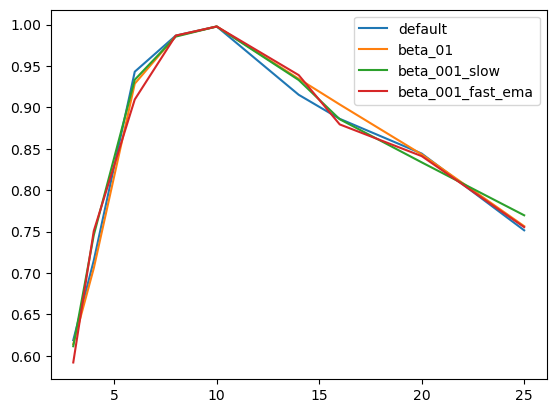

In [14]:
penal_sweep['default']['panel_a'].keys()
for prm in penal_sweep:
    sns.lineplot(data=penal_sweep[prm]['panel_a']['aggregate_r2'], label=prm)

In [19]:
from results import finalize_results_state
pickle.dump(finalize_results_state(penal_sweep['beta_01']), open("penal_beta01.b", "wb"))